In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold

In [2]:
BC_data = load_breast_cancer()
X, y = BC_data.data, BC_data.target

In [3]:
feature_names = BC_data.feature_names

# Create a DataFrame to display dataset summary
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

display(df)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [4]:
variances=[X[:,i].var() for i in range(30)]


In [5]:
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

In [6]:
selector.get_support()


array([ True,  True,  True,  True, False, False, False, False, False,
       False,  True,  True,  True,  True, False, False, False, False,
       False, False,  True,  True,  True,  True, False,  True,  True,
       False, False, False])

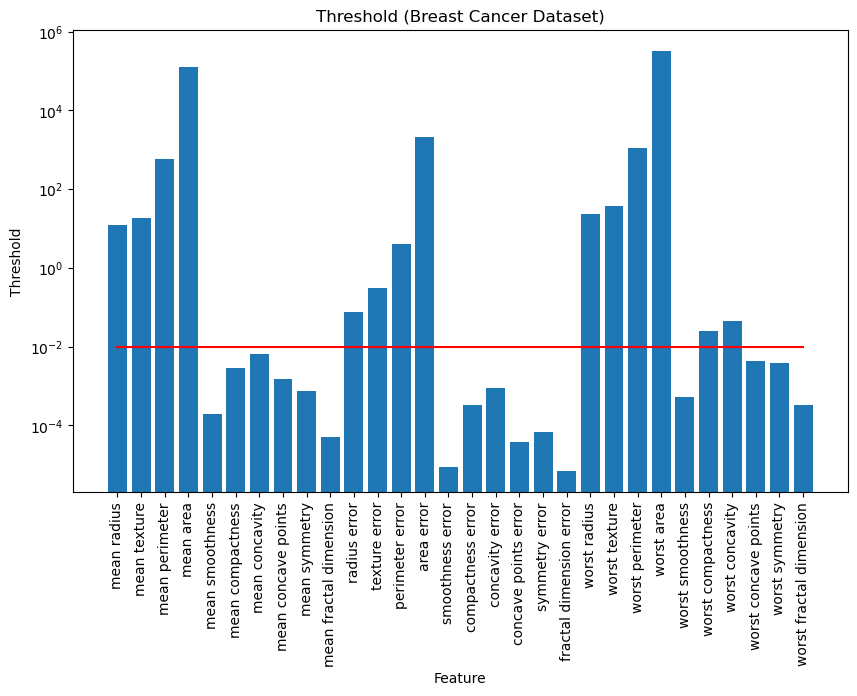

In [7]:
thr=[0.01 for i in range(30)]
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), variances,tick_label=feature_names)
plt.yscale('log')
plt.xlabel("Feature")
plt.ylabel("Threshold")
plt.plot(range(len(feature_names)),thr, c='r')
plt.title("Threshold (Breast Cancer Dataset)")
plt.xticks(rotation=90)
plt.show()


In [8]:
selected_indices = selector.get_support(indices=True)
selected_feature_names = BC_data.feature_names[selected_indices]
print("Selected Features:")
print(selected_feature_names)

Selected Features:
['mean radius' 'mean texture' 'mean perimeter' 'mean area' 'radius error'
 'texture error' 'perimeter error' 'area error' 'worst radius'
 'worst texture' 'worst perimeter' 'worst area' 'worst compactness'
 'worst concavity']


In [9]:
k_best_features = 10
selector = SelectKBest(score_func=chi2, k=k_best_features)
X_new = selector.fit_transform(X, y)

selected_indices = selector.get_support(indices=True)
selected_feature_names = BC_data.feature_names[selected_indices]
print("Selected Features:")
print(selected_feature_names)



Selected Features:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'perimeter error' 'area error' 'worst radius' 'worst texture'
 'worst perimeter' 'worst area']


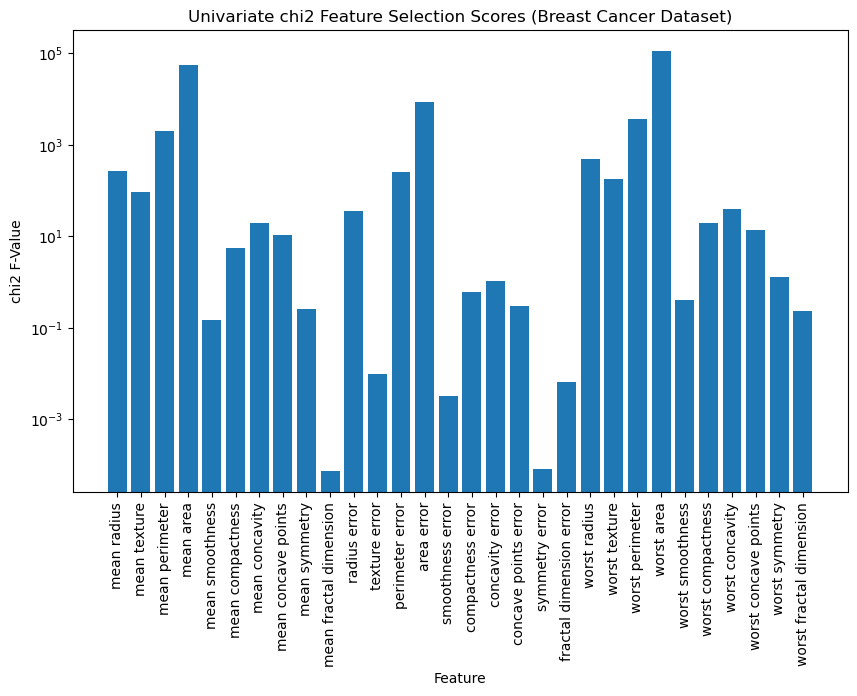

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), selector.scores_, tick_label=feature_names)
plt.yscale('log')
plt.xlabel("Feature")
plt.ylabel("chi2 F-Value")
plt.title("Univariate chi2 Feature Selection Scores (Breast Cancer Dataset)")
plt.xticks(rotation=90)
plt.show()

In [11]:
num_features_to_select = 10 
selector = SelectKBest(score_func=f_classif, k=num_features_to_select)
X_new = selector.fit_transform(X, y)

In [12]:
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = feature_names[selected_feature_indices]

print("Selected Features:")
print(selected_feature_names)


Selected Features:
['mean radius' 'mean perimeter' 'mean area' 'mean concavity'
 'mean concave points' 'worst radius' 'worst perimeter' 'worst area'
 'worst concavity' 'worst concave points']


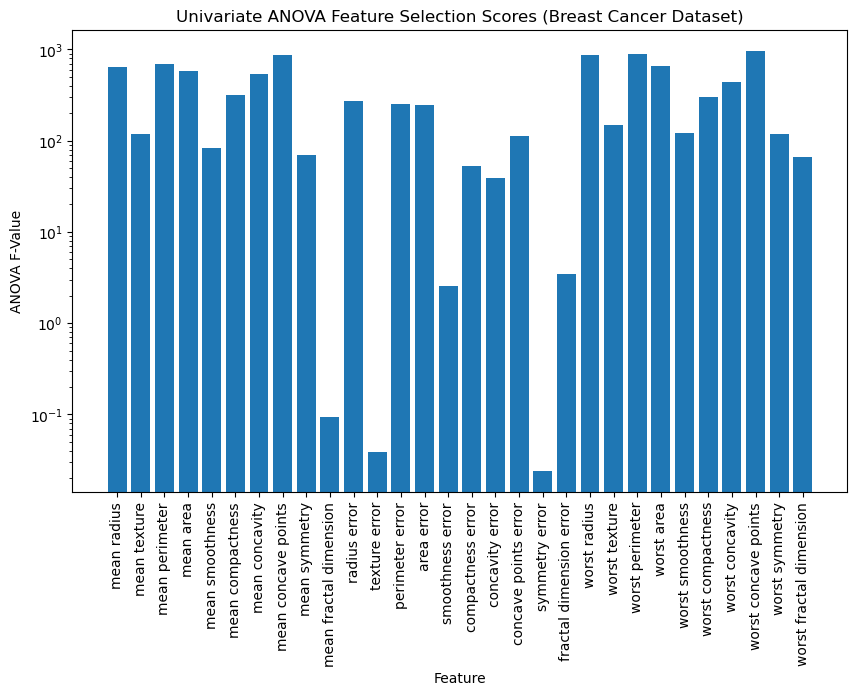

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), selector.scores_, tick_label=feature_names)
plt.yscale('log')
plt.xlabel("Feature")
plt.ylabel("ANOVA F-Value")
plt.title("Univariate ANOVA Feature Selection Scores (Breast Cancer Dataset)")
plt.xticks(rotation=90)
plt.show()

In [14]:

correlation_matrice=df.corr()
display(correlation_matrice)



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


<Axes: >

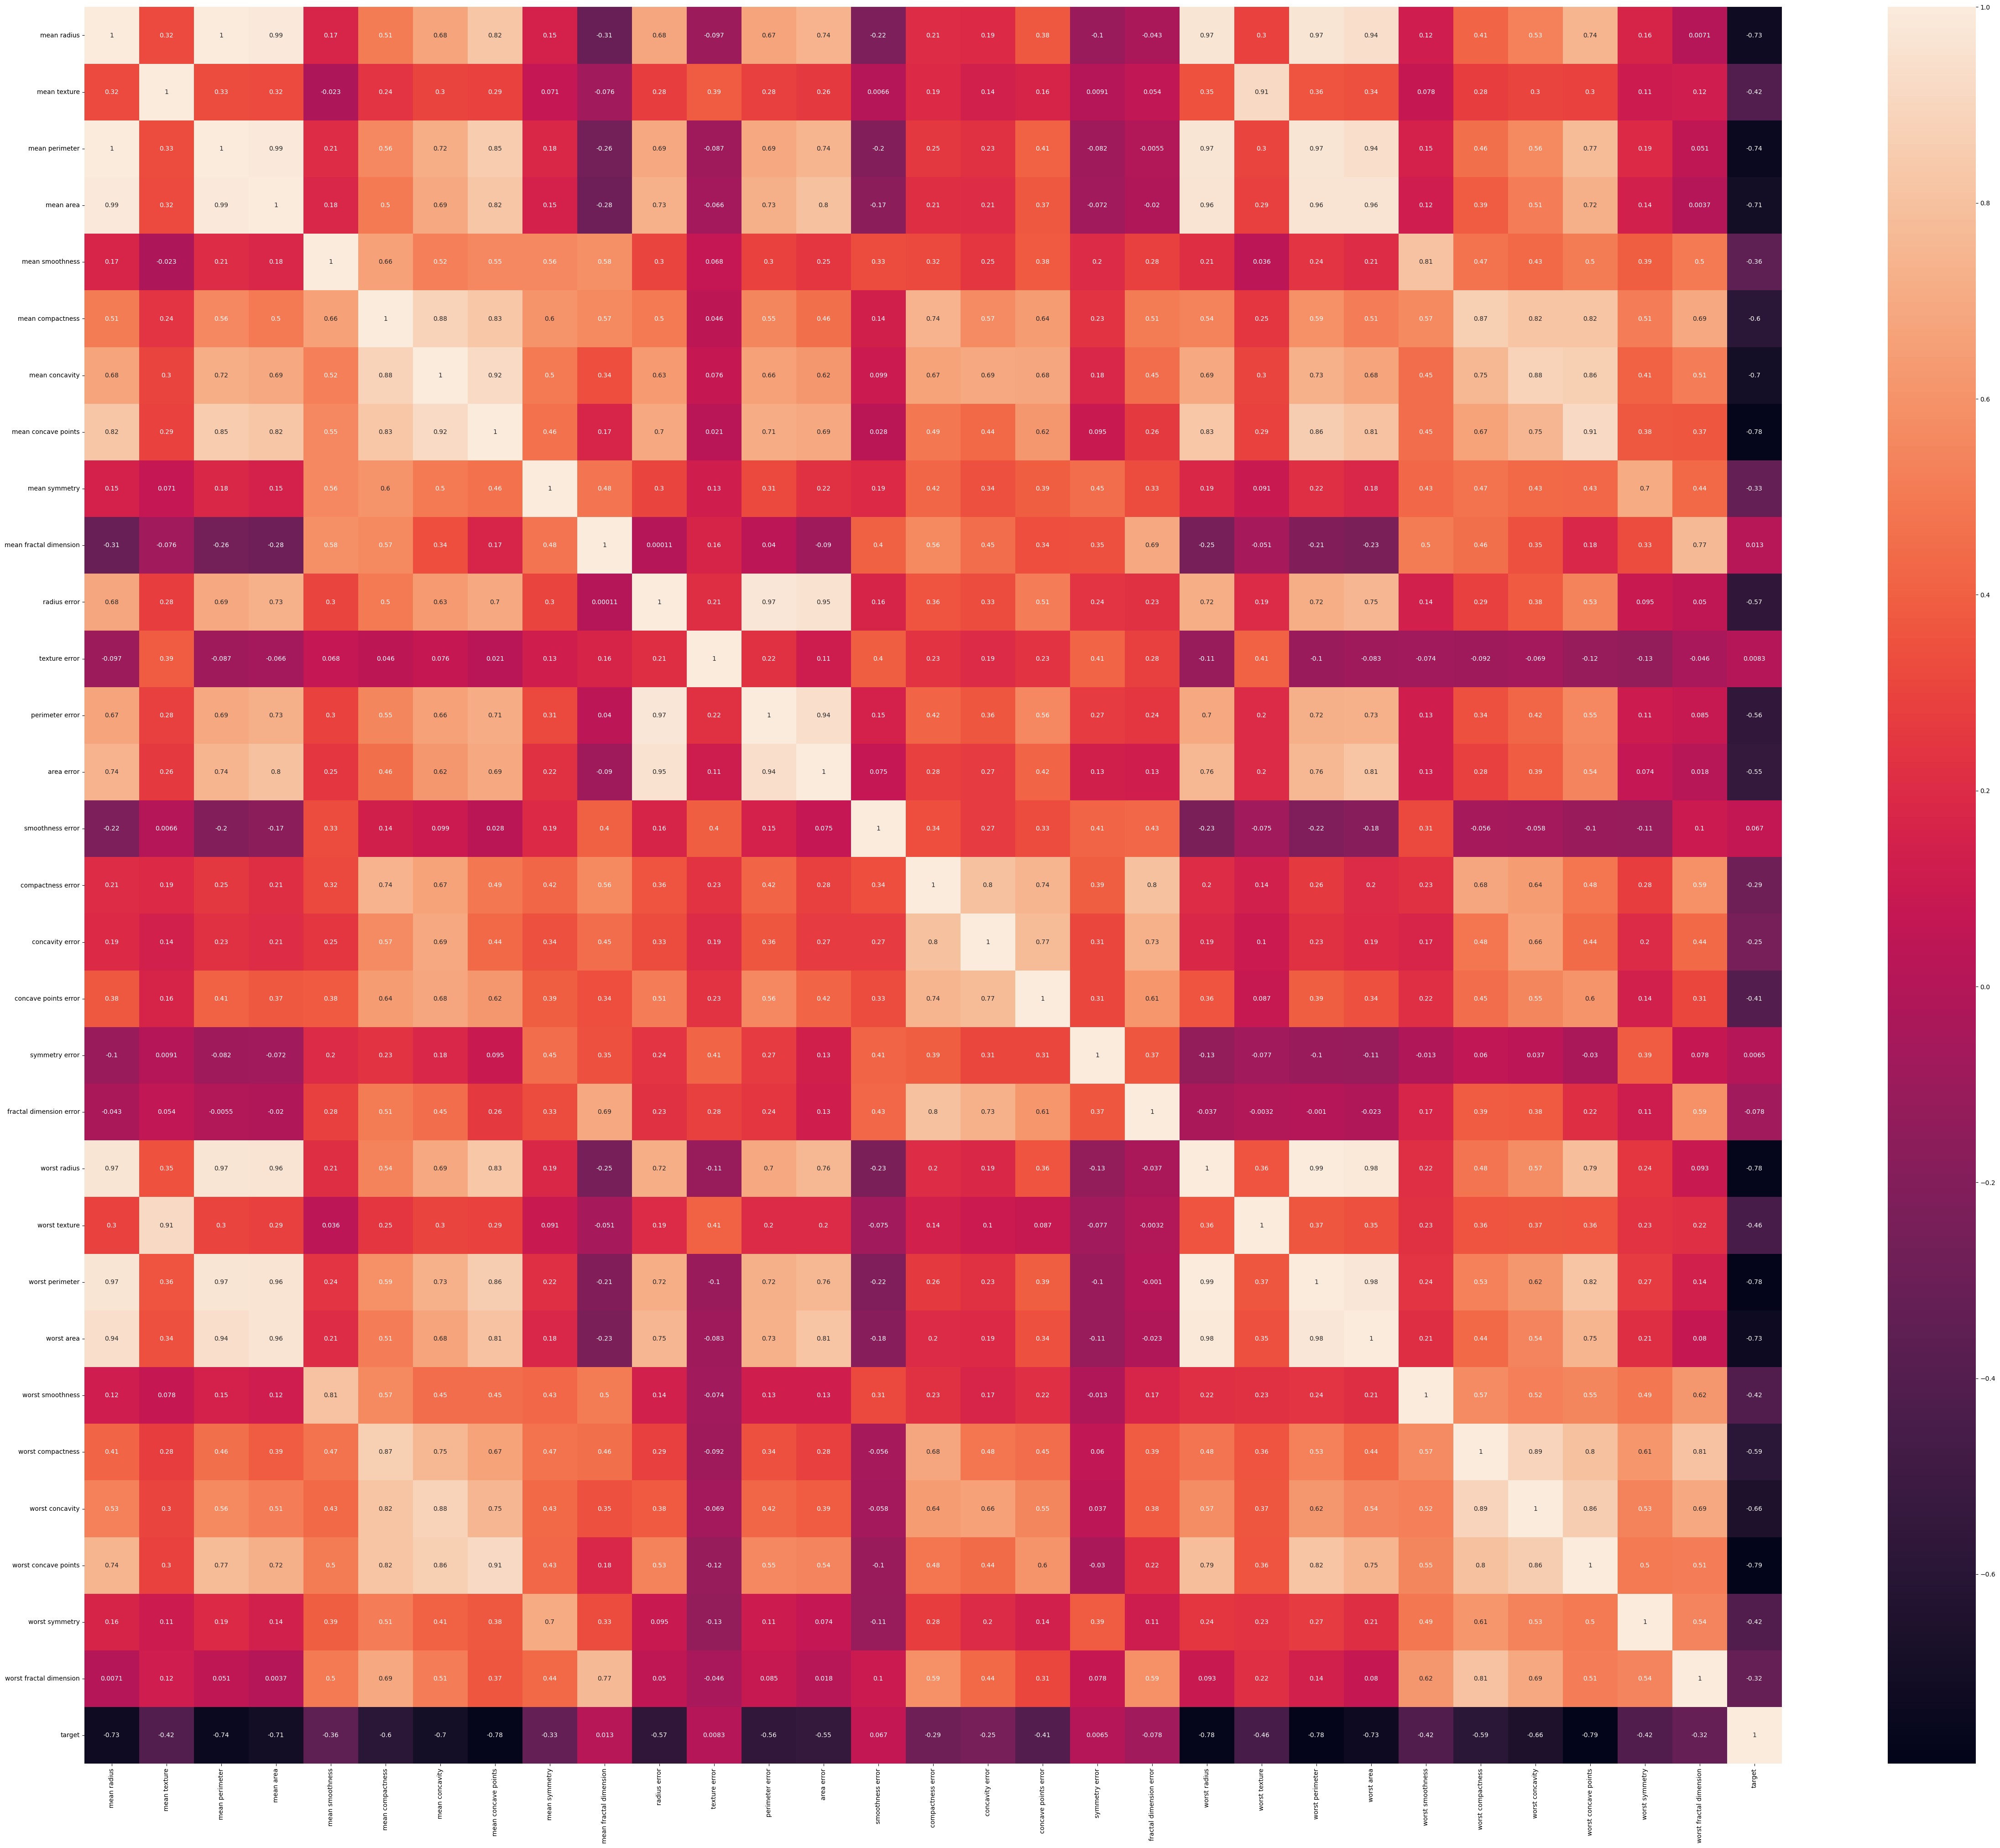

In [15]:
plt.figure(figsize=(60, 50))
sns.heatmap(correlation_matrice, annot=True)


In [16]:
dfnew=pd.DataFrame(X_new)
dfnew['target']=y
display(dfnew)

,0,1,2,3,4,5,6,7,8,9,target
0,17.99,122.80,1001.0,0.30010,0.14710,25.380,184.60,2019.0,0.7119,0.2654,0
1,20.57,132.90,1326.0,0.08690,0.07017,24.990,158.80,1956.0,0.2416,0.1860,0
2,19.69,130.00,1203.0,0.19740,0.12790,23.570,152.50,1709.0,0.4504,0.2430,0
3,11.42,77.58,386.1,0.24140,0.10520,14.910,98.87,567.7,0.6869,0.2575,0
4,20.29,135.10,1297.0,0.19800,0.10430,22.540,152.20,1575.0,0.4000,0.1625,0
...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,142.00,1479.0,0.24390,0.13890,25.450,166.10,2027.0,0.4107,0.2216,0
565,20.13,131.20,1261.0,0.14400,0.09791,23.690,155.00,1731.0,0.3215,0.1628,0
566,16.60,108.30,858.1,0.09251,0.05302,18.980,126.70,1124.0,0.3403,0.1418,0
567,20.60,140.10,1265.0,0.35140,0.15200,25.740,184.60,1821.0,0.9387,0.2650,0


<Axes: >

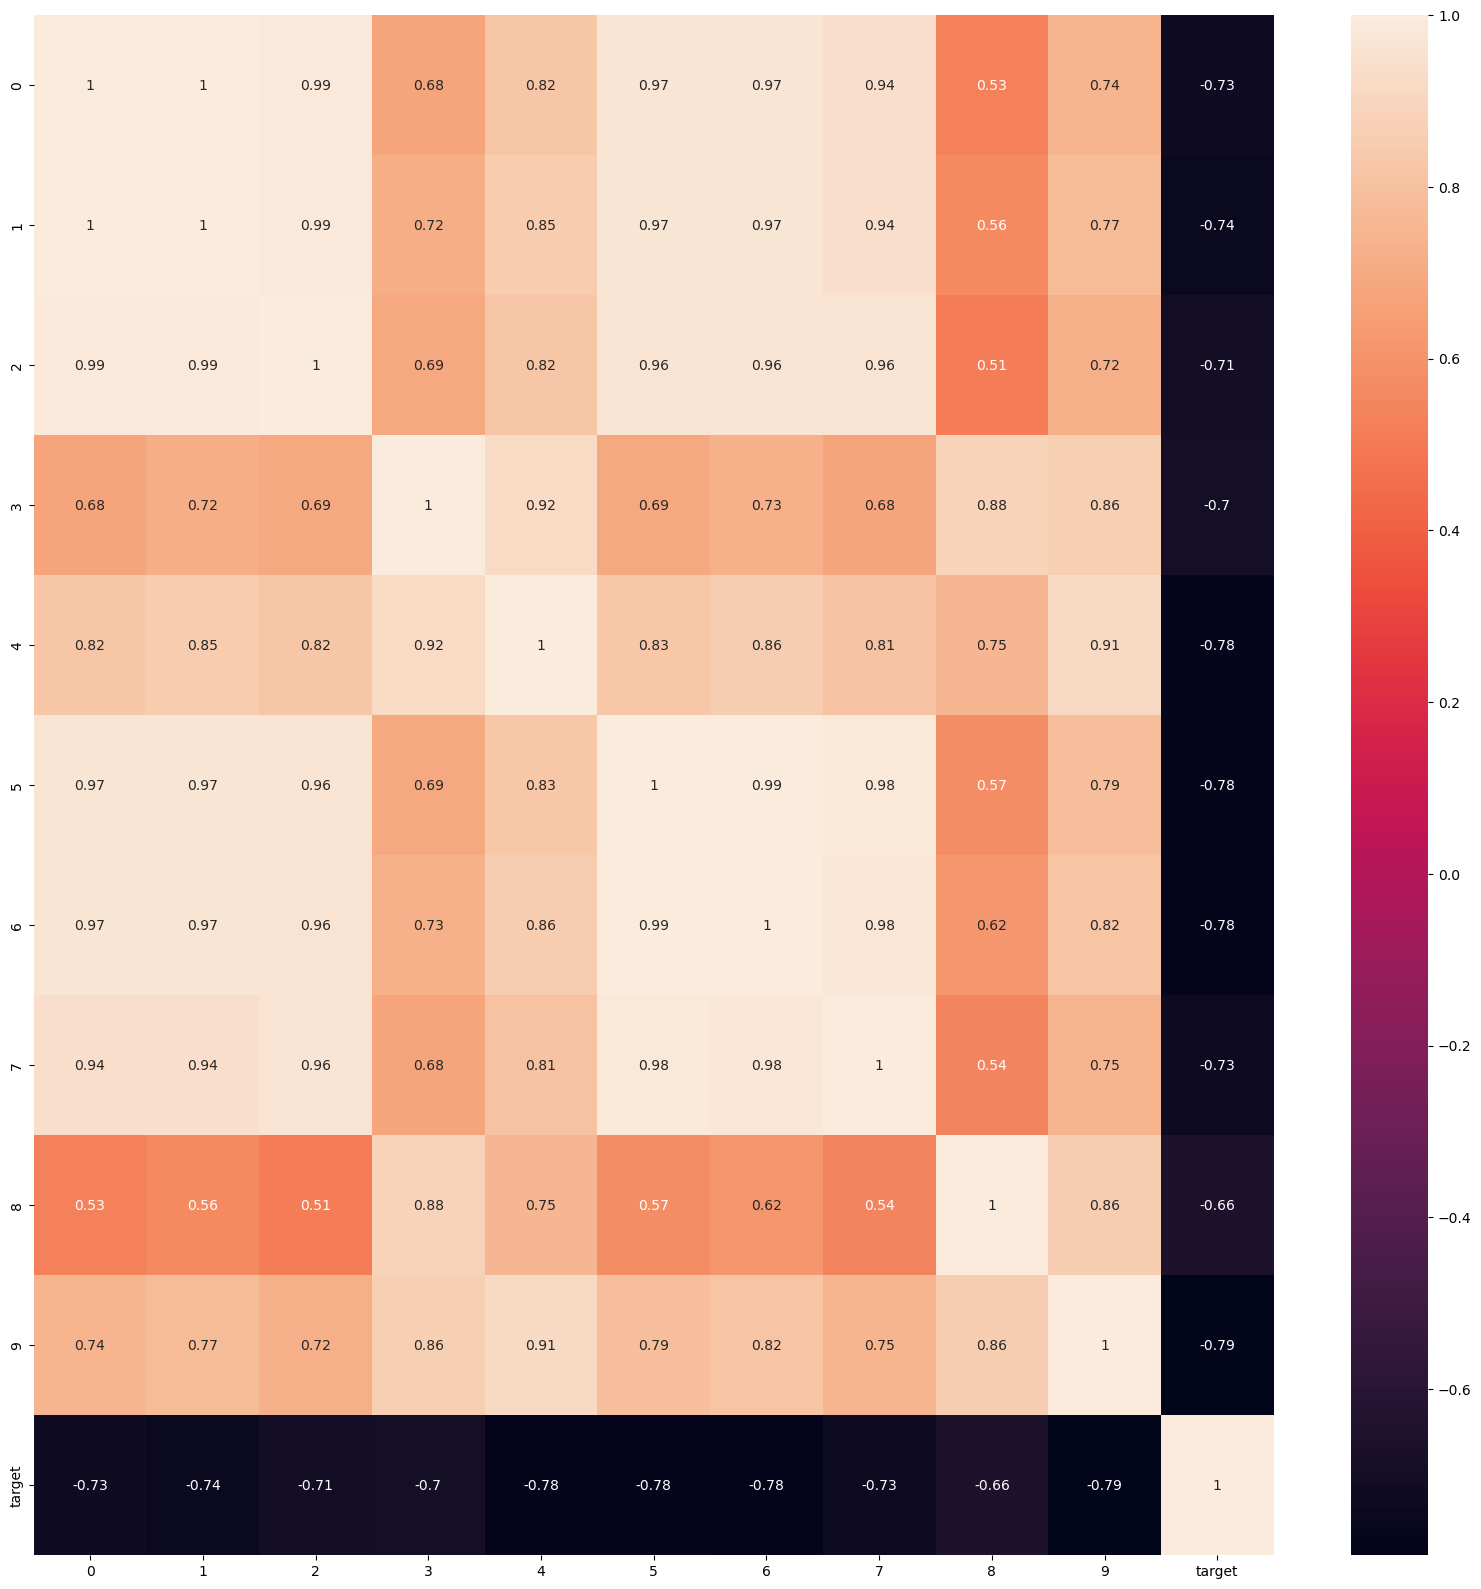

In [17]:
correlation_matrice=dfnew.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrice, annot=True)

In [18]:
from sklearn.decomposition import PCA


pca = PCA(n_components=10)
pca.fit(X)
X_pca= pca.transform(X)



In [19]:
print("explained_variance_ratio {} ".format(pca.explained_variance_ratio_))

print ("explained_variance_ratio_.sum {}".format(pca.explained_variance_ratio_.sum()))


explained_variance_ratio [9.82044672e-01 1.61764899e-02 1.55751075e-03 1.20931964e-04
 8.82724536e-05 6.64883951e-06 4.01713682e-06 8.22017197e-07
 3.44135279e-07 1.86018721e-07] 
explained_variance_ratio_.sum 0.9999998946838418


In [20]:
#preprocessing 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, random_state=49)



[0.9577017783857731, 0.9600820793433653, 0.9671409028727771, 0.9741723666210671, 0.9718467852257182, 0.976497948016416, 0.9741450068399453, 0.9741450068399453, 0.9788508891928865]


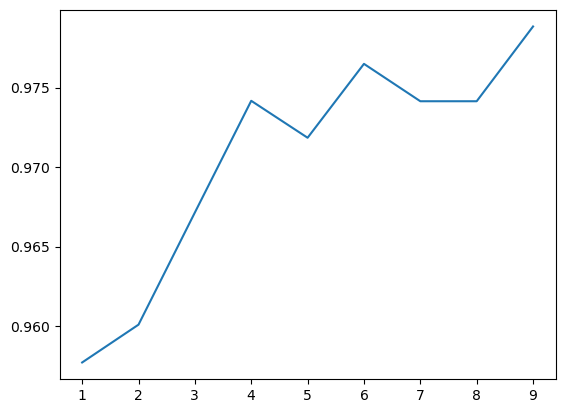

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import  KNeighborsClassifier

val_score=[]
for k in range(1,10):
    score=cross_val_score(KNeighborsClassifier(k), X_train, y_train, cv=5,scoring="accuracy").mean()
    val_score.append(score)
x=np.arange(1,10)
print(val_score)
plt.plot(x,val_score)


In [35]:
#On fixe k à la plus grande valeur
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.9790209790209791

In [24]:
k_best_features = 10
selector = SelectKBest(score_func=chi2, k=k_best_features)
X_new = selector.fit_transform(X_scaled, y)

selected_indices = selector.get_support(indices=True)

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new,y)
   

[0.941313269493844, 0.9272229822161423, 0.9577564979480165, 0.9460465116279071, 0.9577838577291382, 0.9601367989056089, 0.9577838577291382, 0.9624897400820794, 0.9530779753761971]


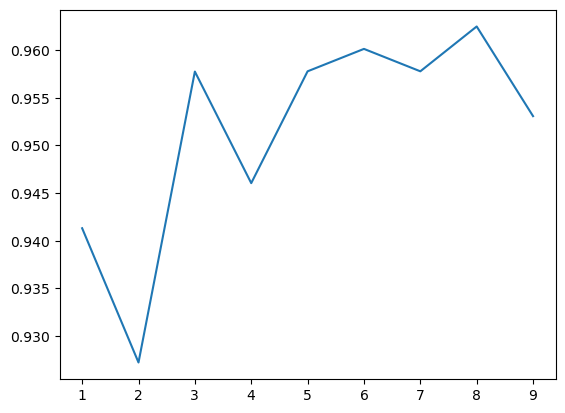

In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import  KNeighborsClassifier

val_score=[]
for k in range(1,10):
    score=cross_val_score(KNeighborsClassifier(k), X_train, y_train, cv=5,scoring="accuracy").mean()
    val_score.append(score)
x=np.arange(1,10)
print(val_score)
plt.plot(x,val_score)

In [36]:
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.9790209790209791

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y)


In [40]:
pca = PCA(n_components=10)
pca.fit(X_scaled)
X_train_pca= pca.transform(X_train)
X_test_pca= pca.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.986013986013986